<a href="https://colab.research.google.com/github/yunbing1999/ai-medical-robotics-exercises/blob/main/exercise_2_1_improved.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 2.1 — Breast Cancer Data Exploration
**AI in Medical Robotics**

Explore measured features, try a classification rule, and compare a chosen threshold with one learned from labelled data.

Run the cells from top to bottom. No new code is required. In Section 7, change the feature or threshold; then rerun Sections 7–9. In Section 8, you can also change the case index.

**Question 1:** Which features and rule would you use? What are the input and output?

**Question 2:** How does an expert-defined rule differ from a rule learned from labelled cases? Give an advantage and a disadvantage of each.

This is a teaching example, not a validated diagnostic system.

Dataset: [UCI Breast Cancer Wisconsin (Diagnostic)](https://doi.org/10.24432/C5DW2B), accessed through scikit-learn.

## 1. Import libraries
Run once before the other sections.

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.datasets import load_breast_cancer

sns.set_theme(style="whitegrid", font_scale=1.15)
PALETTE = {"Benign": "#7FD4E3", "Malignant": "#F4A6C8"}
CLASS_ORDER = ["Benign", "Malignant"]

## 2. Load and browse the data
Each row is one case. The four measurements are available input features. `Diagnosis` is the known label.

In Colab, the table contains all 569 rows and shows 10 per page. Use its controls to browse, sort, or filter. The plots always use the complete dataset, regardless of the table page or filter.

In [23]:
data = load_breast_cancer()
rename_map = {
    "mean radius": "radius_mean",
    "mean texture": "texture_mean",
    "mean perimeter": "perimeter_mean",
    "mean area": "area_mean",
}

df = pd.DataFrame(data.data, columns=data.feature_names)
df = df[list(rename_map)].rename(columns=rename_map)
# Use the dataset's label names instead of assuming a numeric class order.
df["Diagnosis"] = [data.target_names[label].capitalize() for label in data.target]
FEATURES = list(rename_map.values())

print(f"{len(df)} cases loaded. Four features and one known label per case.")

# Paginated table in Colab; a small preview in other notebook environments.
try:
    from google.colab import data_table
except ImportError:
    display(df.head(10))
    print("Preview: 10 rows. The full dataset is stored in df.")
else:
    display(data_table.DataTable(df, include_index=True, num_rows_per_page=10))

569 cases loaded. Four features and one known label per case.


,radius_mean,texture_mean,perimeter_mean,area_mean,Diagnosis
0,17.99,10.38,122.80,1001.0,Malignant
1,20.57,17.77,132.90,1326.0,Malignant
2,19.69,21.25,130.00,1203.0,Malignant
3,11.42,20.38,77.58,386.1,Malignant
4,20.29,14.34,135.10,1297.0,Malignant
...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,Malignant
565,20.13,28.25,131.20,1261.0,Malignant
566,16.60,28.08,108.30,858.1,Malignant
567,20.60,29.33,140.10,1265.0,Malignant


## 3. Countplot — how many cases are in each class?
Are the classes equally frequent?

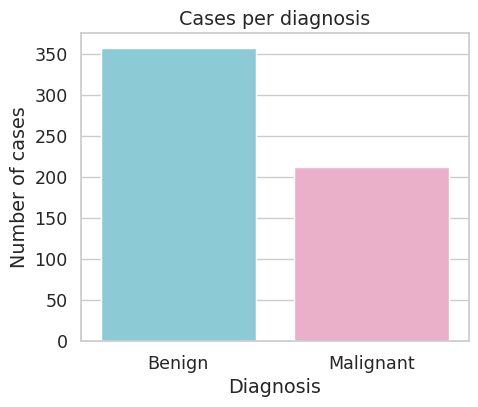

Diagnosis
Benign       357
Malignant    212
Name: count, dtype: int64


In [24]:
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="Diagnosis", hue="Diagnosis", order=CLASS_ORDER,
              palette=PALETTE, legend=False)
plt.title("Cases per diagnosis")
plt.ylabel("Number of cases")
plt.show()

print(df["Diagnosis"].value_counts().reindex(CLASS_ORDER))

## 4. Pairplot — compare features
Each dot in a scatter plot is one case; its colour shows the known diagnosis. Diagonal panels show distributions.

**For Question 1:** Start with radius versus perimeter, then radius versus texture. Where do the two classes overlap? Which feature might support a simple rule?

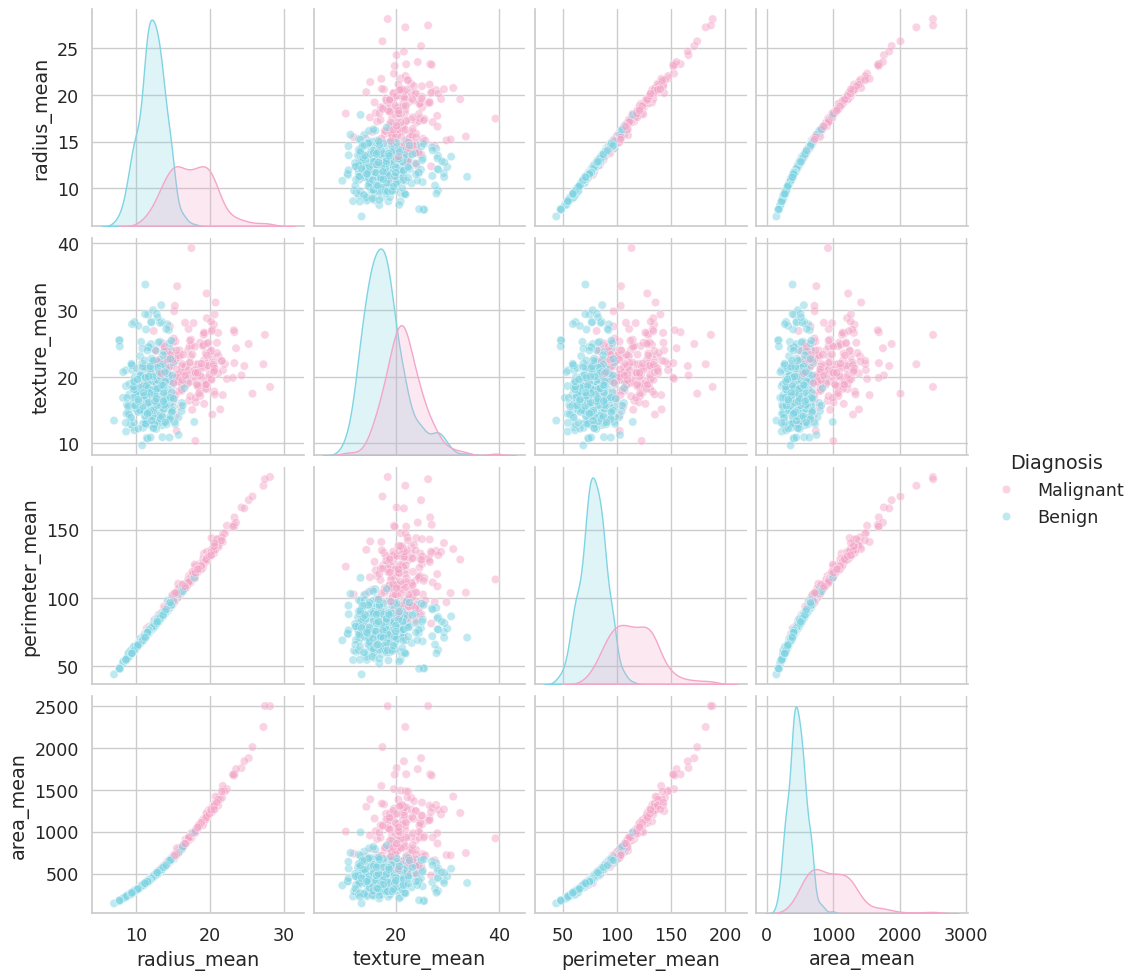

In [25]:
sns.pairplot(df, vars=FEATURES, hue="Diagnosis", palette=PALETTE,
             diag_kind="kde", plot_kws={"alpha": 0.5})
plt.show()

## 5. Correlation heatmap — look for related features
**For Question 1:** Do radius, perimeter, and area provide largely overlapping size information?

This chart measures linear relationships between features, not how well they predict diagnosis. Lower correlation makes texture a candidate for additional information; it does not prove that adding texture improves a classifier.

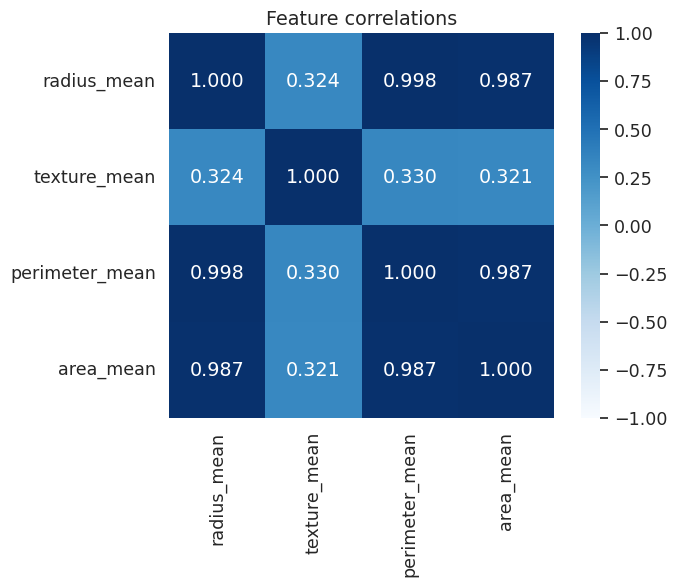

In [26]:
correlation = df[FEATURES].corr()
plt.figure(figsize=(7, 5))
sns.heatmap(correlation, annot=True, fmt=".3f", cmap="Blues",
            vmin=-1, vmax=1, square=True)
plt.title("Feature correlations")
plt.show()

## 6. Boxplots — compare class distributions
The line in each box is the median. The box covers the middle 50% of values.

**For Question 1:** Which features show a visible difference between classes? Use this as a clue, not proof of which feature gives the best classification accuracy.

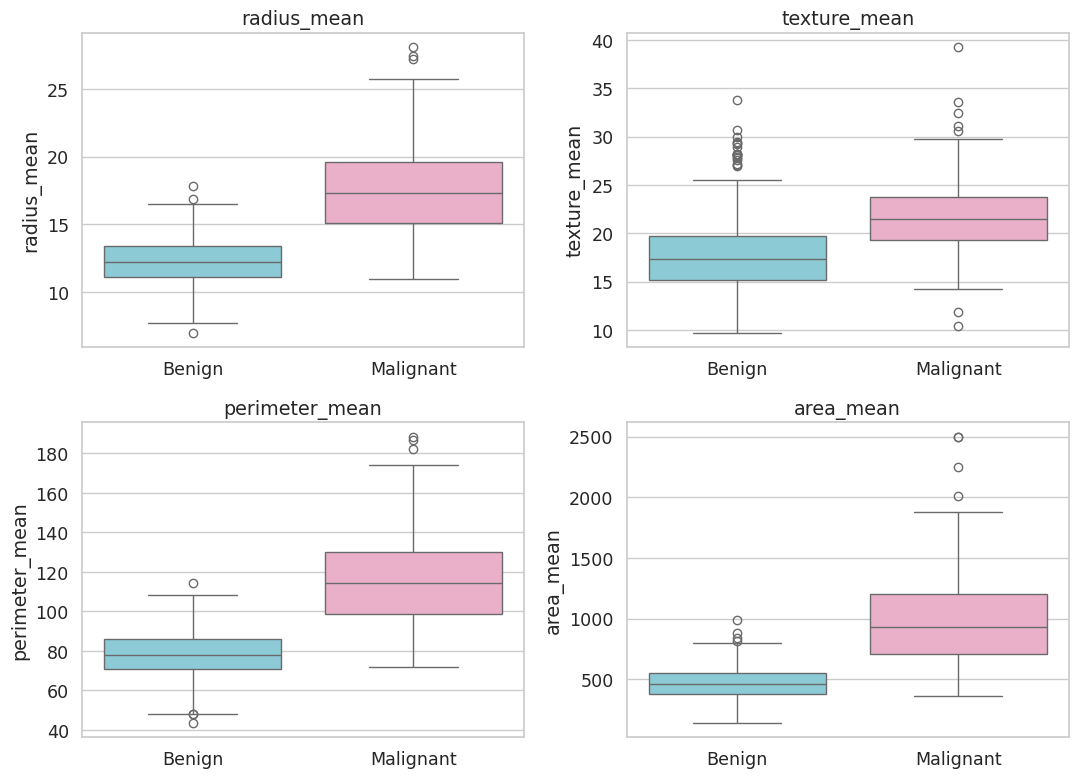

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, column in zip(axes.flat, FEATURES):
    sns.boxplot(data=df, x="Diagnosis", y=column, hue="Diagnosis",
                order=CLASS_ORDER, palette=PALETTE, legend=False, ax=ax)
    ax.set_title(column)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

## 7. Try a threshold rule
**Edit here:** start with `radius_mean` and a threshold of `15.0`. Try `14.0` or `16.0`.

Predict what will happen to missed malignant cases before running the cell.

You may choose another feature from `FEATURES`, but choose a threshold appropriate to its scale using the boxplots. After changing this cell, rerun Sections 8 and 9.

The rule predicts Malignant above the threshold and Benign otherwise. Its input is **one selected feature**.

Rule: radius_mean > 15.0 -> Malignant; otherwise Benign
Correct: 506/569 (88.9%)
Malignant cases missed: 51
Benign cases wrongly called Malignant: 12


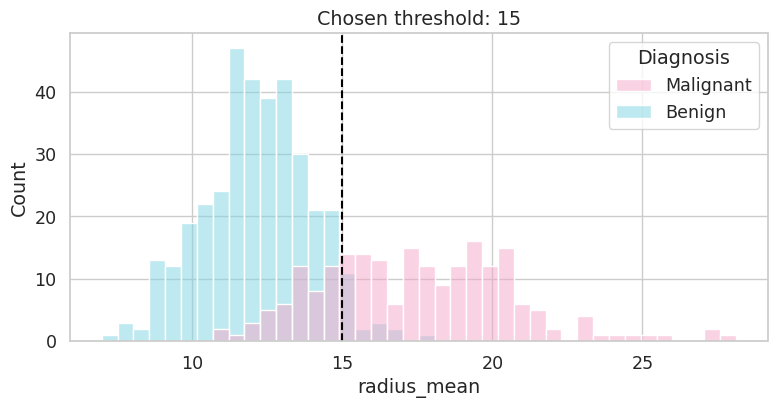

In [28]:
selected_feature = "radius_mean"  # EDIT: choose one of FEATURES
threshold = 15.0                  # EDIT: choose a cutoff

prediction = np.where(df[selected_feature] > threshold, "Malignant", "Benign")
correct = (prediction == df["Diagnosis"]).sum()
missed_malignant = ((prediction == "Benign") & (df["Diagnosis"] == "Malignant")).sum()
false_alarm = ((prediction == "Malignant") & (df["Diagnosis"] == "Benign")).sum()

print(f"Rule: {selected_feature} > {threshold} -> Malignant; otherwise Benign")
print(f"Correct: {correct}/{len(df)} ({correct / len(df):.1%})")
print(f"Malignant cases missed: {missed_malignant}")
print(f"Benign cases wrongly called Malignant: {false_alarm}")

plt.figure(figsize=(9, 4))
sns.histplot(data=df, x=selected_feature, hue="Diagnosis", palette=PALETTE,
             bins=40, alpha=0.5)
plt.axvline(threshold, color="black", linestyle="--")
plt.title(f"Chosen threshold: {threshold:g}")
plt.show()

**Pause for Question 1:** Write your rule, including what happens at the threshold. Does it separate all cases correctly? Explain the two kinds of errors.

## 8. One case in, one predicted diagnosis out
Change `case_index` to select a row (0–568). Try 0 and 3 with the radius threshold of 15.

The true label is shown only to check the prediction. It is not an input to the rule.

In [29]:
case_index = 0  # EDIT: choose an integer from 0 to 568
case = df.iloc[case_index]

predicted_diagnosis = "Malignant" if case[selected_feature] > threshold else "Benign"

print(f"Case index: {case_index}")
print(f"INPUT: {selected_feature} = {case[selected_feature]:.2f}")
print(f"RULE: above {threshold} -> Malignant; otherwise Benign")
print(f"OUTPUT: {predicted_diagnosis}")
print(f"Known label (for comparison): {case['Diagnosis']}")

Case index: 0
INPUT: radius_mean = 17.99
RULE: above 15.0 -> Malignant; otherwise Benign
OUTPUT: Malignant
Known label (for comparison): Malignant


## 9. Find a threshold from labelled data
The computer keeps the feature and rule form fixed and searches for a threshold with the highest accuracy on these 569 cases.

We check midpoints between distinct observed values, plus one cutoff at each end. These cover every possible split of the observed data for this rule. If several thresholds tie, we select the first.

**For Question 2:** An expert rule based on independent medical knowledge illustrates knowledge-based AI. Automatically fitting the threshold to labelled data illustrates data-driven AI. Your own choice after examining labelled plots also uses data evidence; being chosen by a human does not make it purely knowledge-based.

Feature: radius_mean
Your threshold: 15 | accuracy: 88.9%
Computer threshold: 15.04 | training accuracy: 89.1%


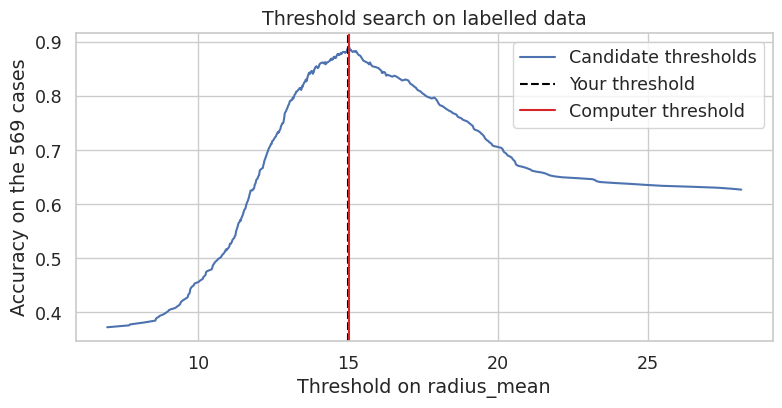

In [30]:
def calculate_accuracy(feature_name, cutoff):
    predicted = np.where(df[feature_name] > cutoff, "Malignant", "Benign")
    return (predicted == df["Diagnosis"]).mean()

values = np.sort(df[selected_feature].unique())
midpoints = (values[:-1] + values[1:]) / 2
# Below the minimum predicts all Malignant; at the maximum predicts all Benign.
candidates = np.concatenate(([np.nextafter(values[0], -np.inf)], midpoints, [values[-1]]))
scores = [calculate_accuracy(selected_feature, cutoff) for cutoff in candidates]

best_index = int(np.argmax(scores))
best_threshold = candidates[best_index]
chosen_accuracy = calculate_accuracy(selected_feature, threshold)

print(f"Feature: {selected_feature}")
print(f"Your threshold: {threshold:g} | accuracy: {chosen_accuracy:.1%}")
print(f"Computer threshold: {best_threshold:.4g} | training accuracy: {scores[best_index]:.1%}")

plt.figure(figsize=(9, 4))
plt.plot(candidates, scores, label="Candidate thresholds")
plt.axvline(threshold, color="black", linestyle="--", label="Your threshold")
plt.axvline(best_threshold, color="tab:red", label="Computer threshold")
plt.xlabel(f"Threshold on {selected_feature}")
plt.ylabel("Accuracy on the 569 cases")
plt.title("Threshold search on labelled data")
plt.legend()
plt.show()

**Interpret the result:** This is training accuracy: the same cases select and evaluate the threshold. A separate test set is needed to estimate performance on unseen cases. The best threshold may differ slightly from a search using a fixed step size.

Both rules are equally easy to read. Data-driven models are not necessarily less interpretable. More data does not automatically improve a rule; it must be used for fitting and the result must be evaluated.

## Back to Exercise 2.1
**Question 1:** State the input, a precise rule, and the predicted output. Give one observation from a plot that supports your choice. A single-feature rule is sufficient. A second feature is a possible extension, not an improvement demonstrated here.

**Question 2:** Identify the expert-defined and data-driven approaches. Discuss an advantage and a disadvantage of each. What does the computer learn here, and what has a human already fixed?